In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import openpyxl
print(openpyxl.__version__)

3.1.5


## Functions

In [19]:
# Categories Sanity Check
def categorical_sanity_check(df, column, valid_values):
    invalid = df[~df[column].isin(valid_values)]
    return invalid[column].value_counts()


# Data Type Checking
def validate_dtypes(df, expected_dtypes: dict):
    mismatches = {}

    for col, expected in expected_dtypes.items():
        if col not in df.columns:
            continue
        actual = str(df[col].dtype)
        # Treat pandas object as string
        if expected == "str" and actual == "object":
            continue
        if actual != expected:
            mismatches[col] = (df[col].dtype, expected)
    return mismatches


# Null Values Checker
def missing_value_report(df):
    return (
        df.isnull()
          .sum()
          .to_frame("missing_count")
          .assign(missing_pct=lambda x: x.missing_count / len(df))
          .query("missing_count > 0")
    )

# Outlier Detection and Distribution
def plot_distribution(df, col):
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

def plot_box_plot(df, col):
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()


In [47]:
# Load data (Demographic)

FILE_NAME = "raw_data.xlsx"
DATA_PATH = Path(FILE_NAME)
df = pd.read_excel(DATA_PATH)

SHEET_NAME = "Demographic"
df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)

df.head()

,CustomerId,Name,Gender,Age,Salary,LocationId,Churned
0,15634602,Hargrave,Female,42,101348.88,2,1
1,15647311,Hill,Female,41,112542.58,6,0
2,15619304,Onio,Female,42,113931.57,4,1
3,15701354,Boni,Female,39,93826.63,1,0
4,15737888,Mitchell,Female,43,79084.10,4,0


In [5]:
# from functions import categorical_sanity_check

In [6]:
# Remove columns
df = df.drop(['Name'], axis=1)

In [7]:
# Export file

OUTPUT_DIR = Path("data") / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

file_path = OUTPUT_DIR / "demographic.csv"

df.to_csv(file_path, index=False)

## Categories Sanity Check

In [8]:
categorical_sanity_check(df, 
                          'Gender',
                          ['Male','Female'])

Series([], Name: count, dtype: int64)

In [9]:
categorical_sanity_check(df,
                          'LocationId',
                           [1,2,3,4,5,6])

Series([], Name: count, dtype: int64)

In [10]:
categorical_sanity_check(df,
                          'Churned',
                           [0,1])

Series([], Name: count, dtype: int64)

## Data Type Checking

In [11]:
expected_dtypes = {
    'Name': 'str',
    'Gender': 'str',
    'Age': 'int64',
    'Salary': 'float64',
    'LocationId': 'int64',
    'Churned': 'int64'
}


validate_dtypes(df,
                expected_dtypes)

{}

## Null Values Check

In [12]:
missing_value_report(df)

,missing_count,missing_pct


## Outlier Detection and Distribution

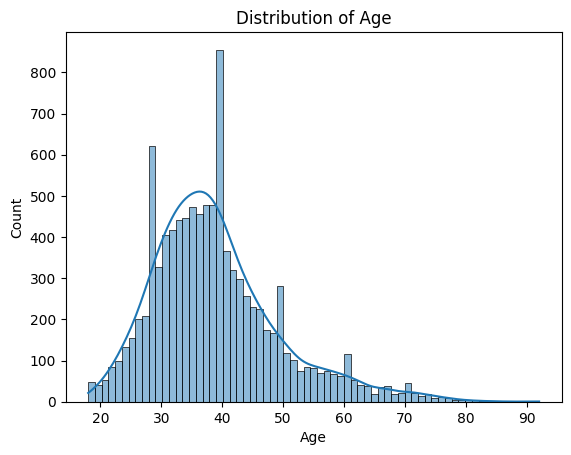

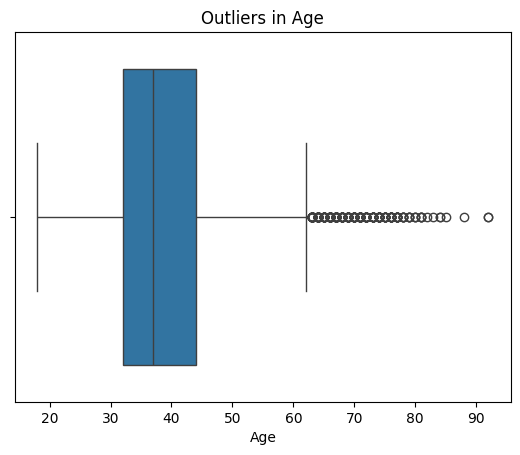

In [38]:
plot_distribution(df, 'Age')
plot_box_plot(df, 'Age')

In [48]:
# Load data (Account)

FILE_NAME = "raw_data.xlsx"
DATA_PATH = Path(FILE_NAME)
df = pd.read_excel(DATA_PATH)

SHEET_NAME = "Account"
df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)

df.head()

,AccountId,CustomerId,Tenure,Balance,NumProducts,HasCreditCard,IsActive
0,A15634602SID,15634602,2,NaN,1,1,1
1,A15647311SID,15647311,1,83807.86,1,0,1
2,A15619304SID,15619304,8,159660.80,3,1,0
3,A15701354SID,15701354,1,NaN,2,0,0
4,A15737888SID,15737888,2,125510.82,1,1,1


In [15]:
categorical_sanity_check(df, 
                          'HasCreditCard',
                          [0,1])

Series([], Name: count, dtype: int64)

In [16]:
categorical_sanity_check(df, 
                          'IsActive',
                          [0,1])

Series([], Name: count, dtype: int64)

In [17]:
expected_dtypes = {
    'Tenure': 'int64',
    'Balance': 'float64',
    'NumProducts': 'int64',
    'HasCreditCard': 'int64',
    'IsActive': 'int64',
}


validate_dtypes(df,
                expected_dtypes)

{}

In [22]:
# Null
missing_value_report(df)

,missing_count,missing_pct
Balance,3617,0.3617


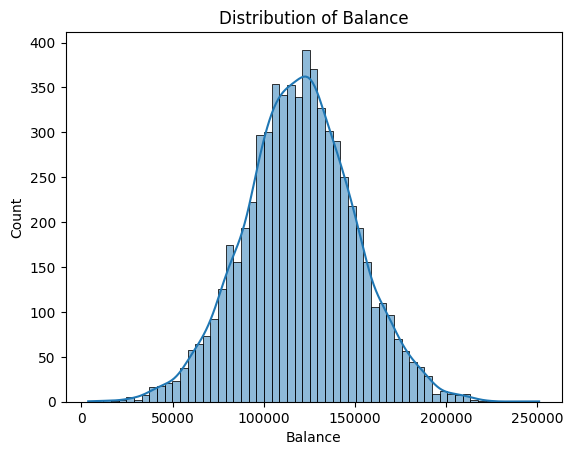

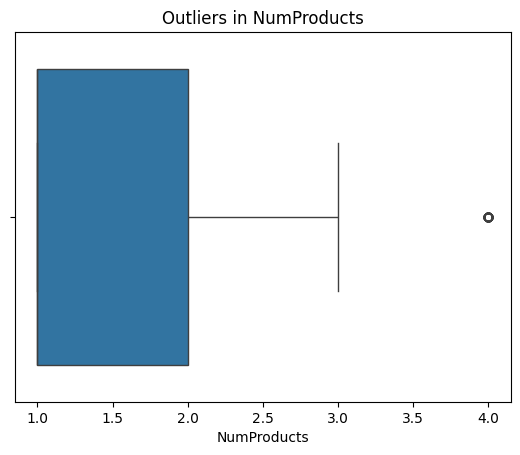

In [28]:
# Outlier Detection and Distribution

# plot_distribution(df, 'Tenure')
# plot_box_plot(df, 'Tenure')

plot_distribution(df, 'Balance')
# plot_box_plot(df, 'Balance')

# plot_distribution(df, 'NumProducts')
plot_box_plot(df, 'NumProducts')




In [42]:
# Dealing with missing values
df['Balance'] = df['Balance'].fillna(df['Balance'].mean())

missing_value_report(df)

,missing_count,missing_pct


In [43]:
# Remove columns
df = df.drop(['AccountId'], axis=1)

In [45]:
# Export file

OUTPUT_DIR = Path("data") / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

file_path = OUTPUT_DIR / "account.csv"

df.to_csv(file_path, index=False)

In [49]:
# Load data (Account)

FILE_NAME = "raw_data.xlsx"
DATA_PATH = Path(FILE_NAME)
df = pd.read_excel(DATA_PATH)

SHEET_NAME = "Location"
df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)

df.head()

,LocationId,Geography
0,1,Germany
1,2,France
2,3,Spain
3,4,UK
4,5,Canada


In [50]:
# Export file

OUTPUT_DIR = Path("data") / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

file_path = OUTPUT_DIR / "location.csv"

df.to_csv(file_path, index=False)